In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split


from pathlib import Path

In [56]:
DATA = Path('..') / 'data'
df = pd.read_csv(DATA / "AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# EDA superficial

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

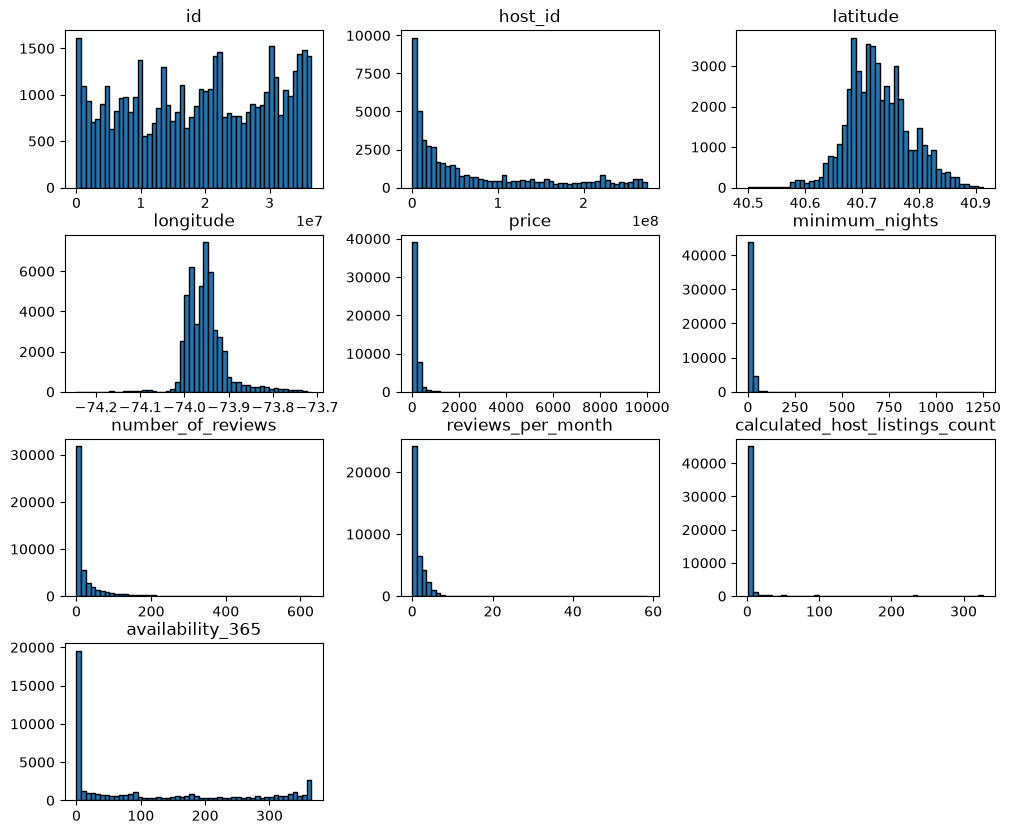

In [66]:
df.hist(edgecolor='black', bins=50, grid=False, figsize=(12,10))
plt.show()

En muchas features se pueden ver la presencia de outliers, por eso son tan asimetricas los histogramas y ademas aparece un rango bastante amplio que parece que no tienen valores que caigan en esos rangos

In [60]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [62]:
df.isna().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [63]:
df.shape

(48895, 16)

In [67]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [120]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [124]:
df.groupby(by='neighbourhood_group')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
neighbourhood_group,,,
Manhattan,196.875814,150.0,291.383183
Brooklyn,124.383207,90.0,186.873538
Staten Island,114.812332,75.0,277.620403
Queens,99.517649,75.0,167.102155
Bronx,87.496792,65.0,106.709349


In [128]:
df.groupby(by='room_type')['price'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)

,mean,median,std
room_type,,,
Entire home/apt,211.794246,160.0,284.041611
Private room,89.780973,70.0,160.205262
Shared room,70.127586,45.0,101.725252


Pueden presentar tanta varianza debido a que no es lo mismo un depto entero en Manhattan que en el Bronx

In [133]:
df.groupby(['room_type', 'neighbourhood_group'])['price'].agg(['mean', 'median', 'std'])

mean  median         std
room_type       neighbourhood_group                                
Entire home/apt Bronx                127.506596   100.0   95.027102
                Brooklyn             178.327545   145.0  226.415825
                Manhattan            249.239109   191.0  331.830132
                Queens               147.050573   120.0  129.383208
                Staten Island        173.846591   100.0  394.600216
Private room    Bronx                 66.788344    53.5  107.009071
                Brooklyn              76.500099    65.0  124.713499
                Manhattan            116.776622    90.0  190.191318
                Queens                71.762456    60.0  180.506756
                Staten Island         62.292553    50.0   36.138245
Shared room     Bronx                 59.800000    40.0  101.798871
                Brooklyn              50.527845    36.0   53.444485
                Manhattan             88.977083    69.0   92.416534
                Queens                69.020202    37.0  171.000607
                Staten Island         57.444444    30.0   45.119594

In [134]:
pivot = deptos.pivot_table(values='price', index='neighbourhood_group', columns='room_type', aggfunc=['mean', 'median', 'std'])

pivot

mean                                   median  \
room_type           Entire home/apt Private room Shared room Entire home/apt   
neighbourhood_group                                                            
Bronx                    127.066007    66.291589   48.333333           100.0   
Brooklyn                 179.025137    77.251852   50.631902           145.0   
Manhattan                248.712113   116.565013   89.762274           190.0   
Queens                   145.987036    71.283265   65.641509           120.0   
Staten Island            176.564885    63.625000   52.750000           100.0   

                                                         std               \
room_type           Private room Shared room Entire home/apt Private room   
neighbourhood_group                                                         
Bronx                       53.0        42.5       94.869179   112.887854   
Brooklyn                    65.0        36.0      237.555116   136.417772   
Manhattan                   90.0        69.0      322.070709   196.528180   
Queens                      60.0        35.0      132.384298   196.428644   
Staten Island               52.0        30.0      448.689512    38.682750   

                                 
room_type           Shared room  
neighbourhood_group              
Bronx                 29.076812  
Brooklyn              56.077469  
Manhattan             96.243190  
Queens               171.576911  
Staten Island         45.824978

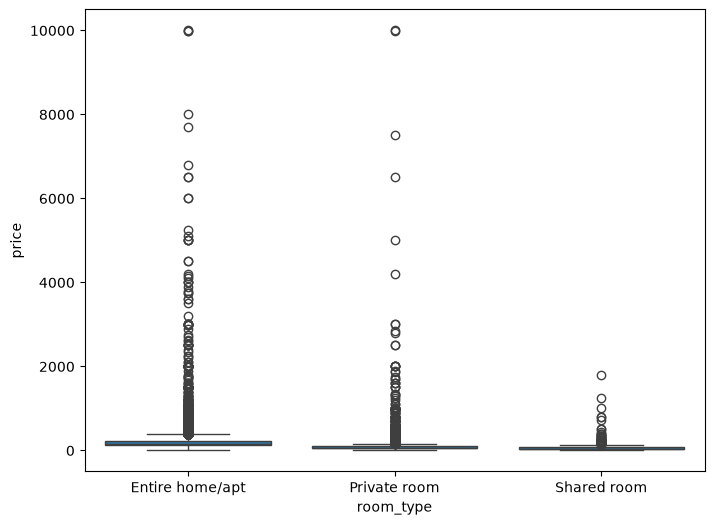

In [125]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(data=deptos, x='room_type', y='price')
plt.show()


# Train y Test set

### Voy a estratificar utilizando el room_type, no se si esta bien esto. VER!

In [68]:
train_set, test_set = train_test_split(df, test_size=0.2, stratify=df['room_type'], random_state=42)

In [71]:
print(df['room_type'].value_counts(normalize=True))
print(train_set['room_type'].value_counts()/train_set.shape[0])

room_type
Entire home/apt    0.519665
Private room       0.456611
Shared room        0.023724
Name: proportion, dtype: float64
room_type
Entire home/apt    0.519659
Private room       0.456616
Shared room        0.023724
Name: count, dtype: float64


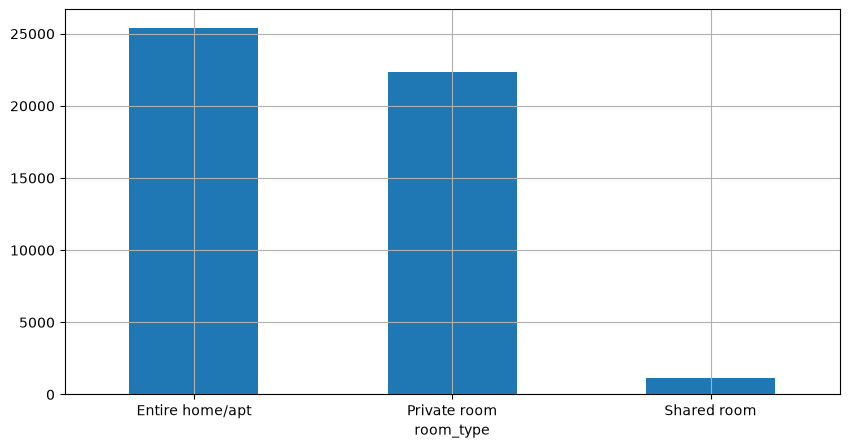

In [77]:
df['room_type'].value_counts().sort_index().plot(kind='bar', grid=True, figsize=(10,5), rot=0)
plt.show()

### Explorar y Visualizar la data


In [80]:
deptos = train_set.copy()

In [91]:
deptos.shape

(39116, 16)

In [89]:
deptos.isna().sum().sort_values(ascending=False).head(4)

last_review          8043
reviews_per_month    8043
host_name              17
name                   14
dtype: int64

In [81]:
deptos.host_id.value_counts()

host_id
219517861    246
107434423    180
30283594      99
137358866     82
16098958      82
            ... 
87553853       1
39927670       1
29110009       1
171212377      1
22410033       1
Name: count, Length: 30910, dtype: int64

In [86]:
deptos.host_name.value_counts()

host_name
Michael               322
David                 312
Sonder (NYC)          246
Alex                  228
John                  226
                     ... 
Aga                     1
Camry                   1
Zoesarah (And) Anu      1
Isidro                  1
Lali                    1
Name: count, Length: 10045, dtype: int64

In [107]:
deptos.neighbourhood_group.value_counts()

neighbourhood_group
Manhattan        17296
Brooklyn         16104
Queens            4539
Bronx              886
Staten Island      291
Name: count, dtype: int64

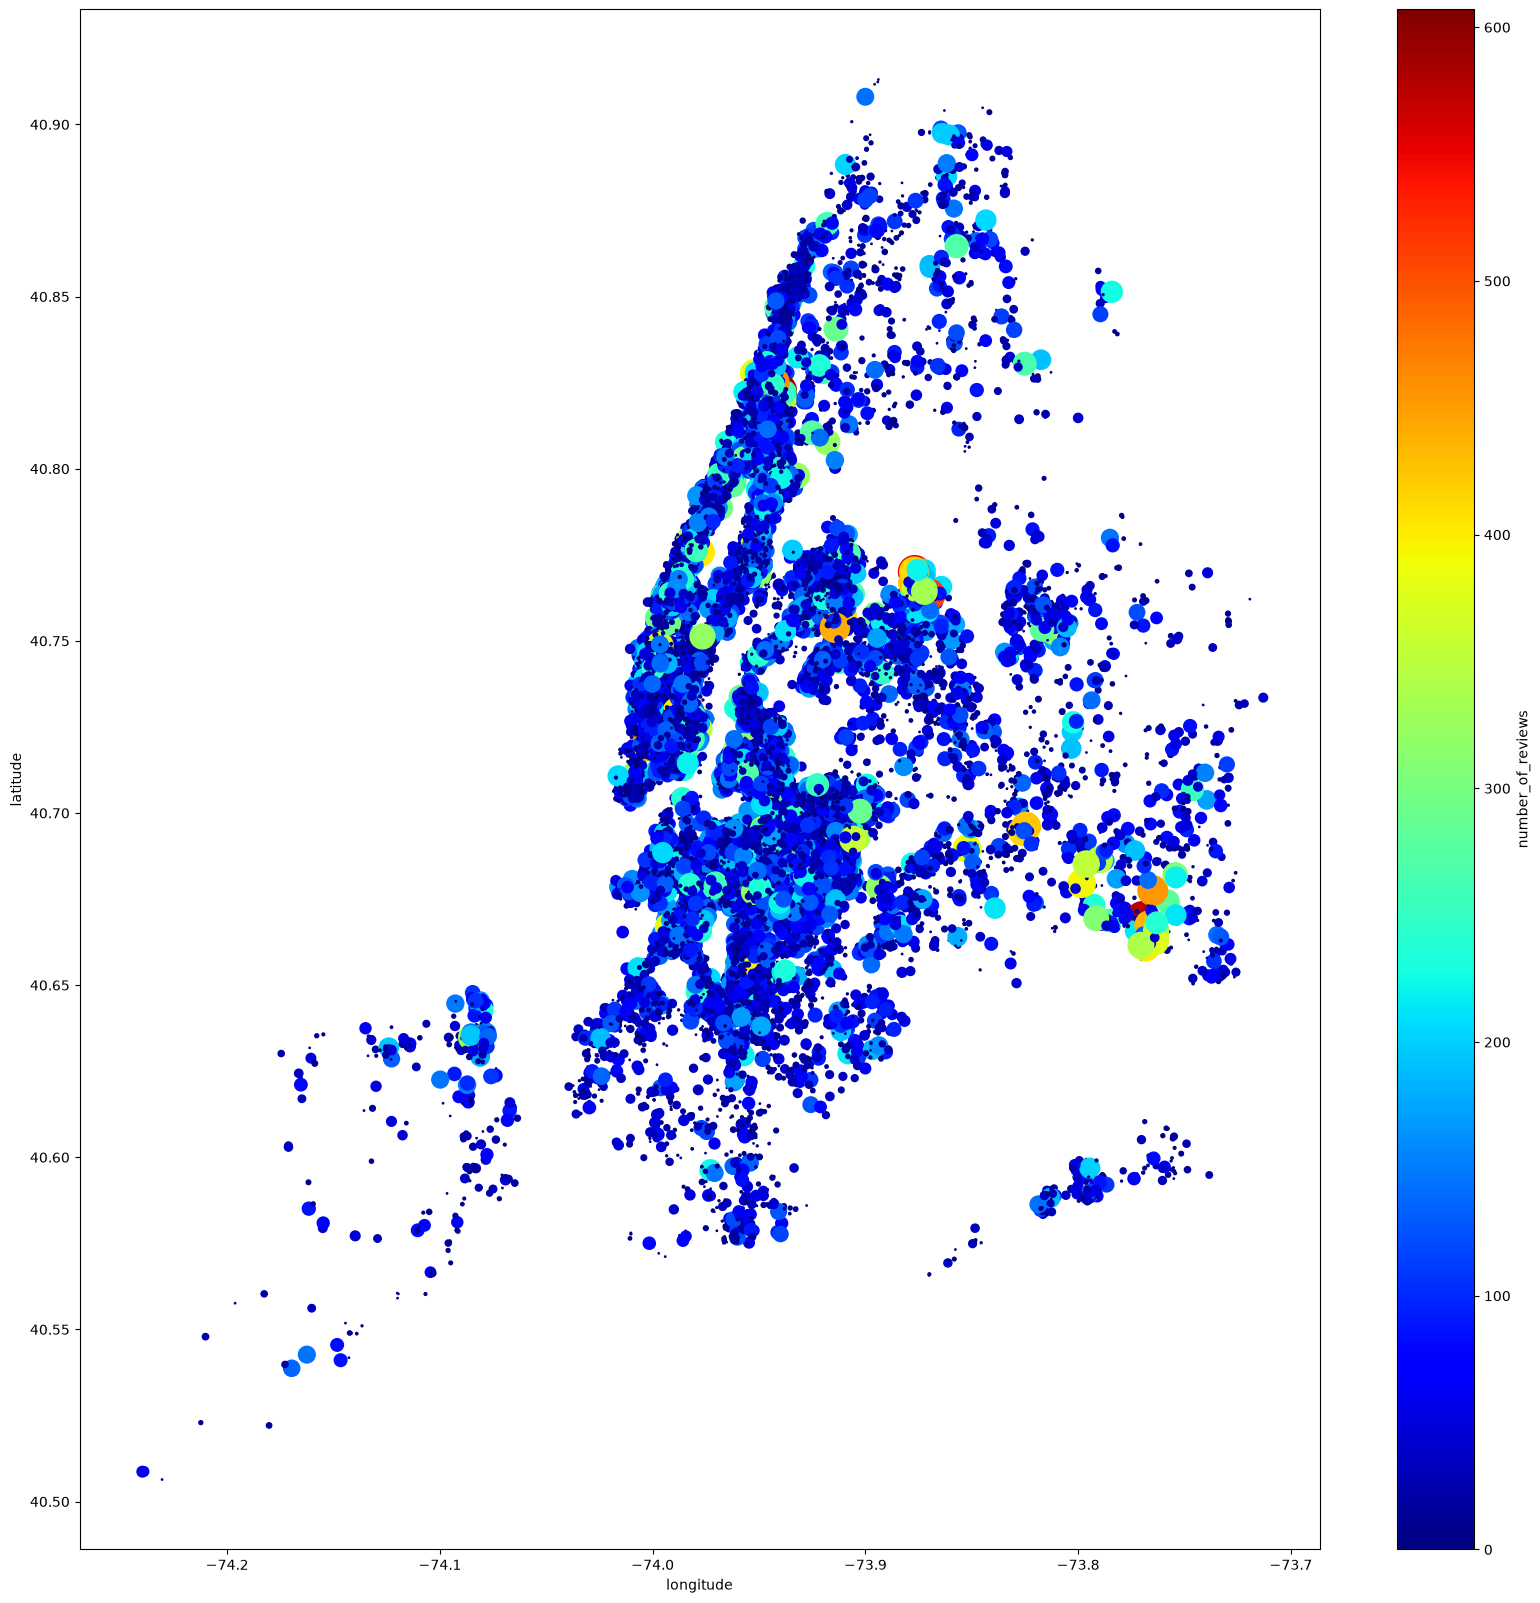

In [113]:
deptos.plot(kind='scatter', x='longitude', y='latitude', c='number_of_reviews', s='number_of_reviews', cmap='jet', figsize=(20,20))

plt.show()

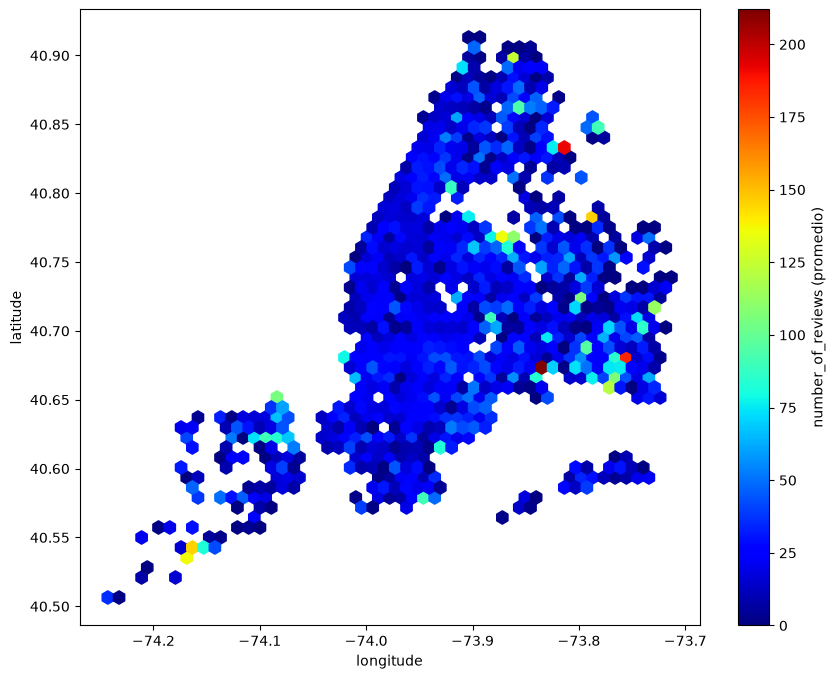

In [106]:
plt.figure(figsize=(10, 8))
plt.hexbin(x=deptos['longitude'], y=deptos['latitude'], C=deptos['number_of_reviews'],
           gridsize=50, cmap='jet', reduce_C_function=np.mean)
plt.colorbar(label='number_of_reviews (promedio)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()


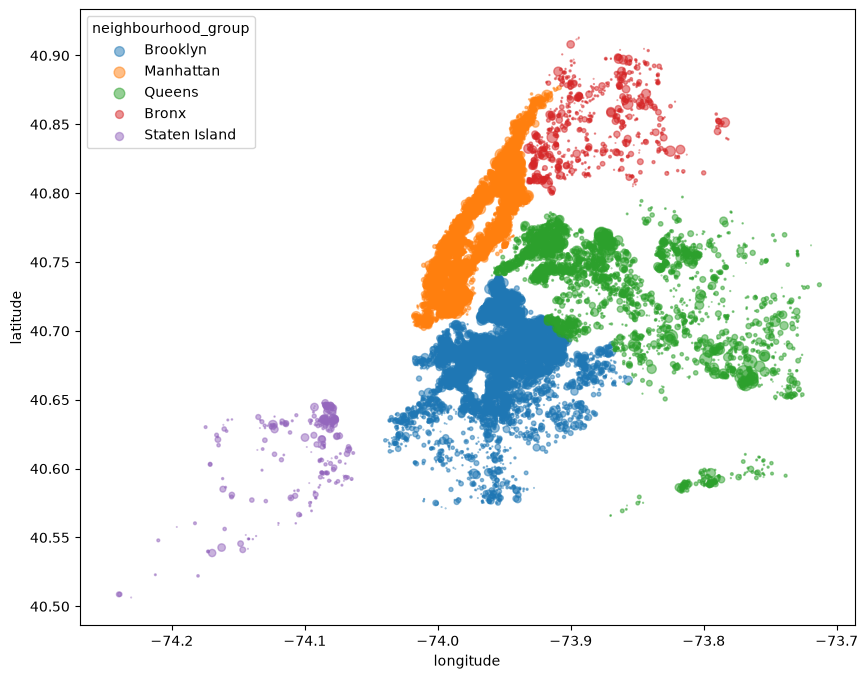

In [110]:
fig, ax = plt.subplots(figsize=(10, 8))
for grupo, color in zip(deptos['neighbourhood_group'].unique(), plt.cm.tab10.colors):
    subset = deptos[deptos['neighbourhood_group'] == grupo]
    ax.scatter(subset['longitude'], subset['latitude'], s=subset['number_of_reviews']/5,
               c=[color], label=grupo, alpha=0.5)
ax.legend(title='neighbourhood_group')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()


Realmente no me queda claro si los precios van a depender tanto de la cantidad de reviews que tenga cada airbnb

### Correlaciones

In [116]:
corr_matrix = deptos.select_dtypes('number').corr()

In [119]:
corr_matrix['price'].sort_values(ascending=False)

price                             1.000000
availability_365                  0.080227
calculated_host_listings_count    0.055503
minimum_nights                    0.046598
latitude                          0.032227
host_id                           0.013888
id                                0.006783
reviews_per_month                -0.029335
number_of_reviews                -0.047357
longitude                        -0.149805
Name: price, dtype: float64